<a href="https://www.kaggle.com/code/avikdas567/ny-real-estate-advanced-dual-avm-nlp-model?scriptVersionId=324461228" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Advanced Real Estate Valuation & Market Intelligence Framework
### New York Residential Transactions 2026

This notebook constructs an end-to-end machine learning and statistical framework utilizing the **New York Sold Real Estate Intelligence 2026** dataset. The analytical objective is to design, validate, and interpret automated valuation models (AVMs) that accurately capture the pricing dynamics of residential transactions across New York State.

#### Core Analytical Strategy
Real estate valuation typically bifurcates into two distinct paradigms based on informational availability:
1. **Model A (Intrinsic Attribute Valuation Model):** Operates under the constraint that listing parameters (such as original asking price) are undisclosed or missing. This relies strictly on localized geographic variables, structural characteristics, and narrative descriptors to predict the final transaction price ($lastSoldPrice$).
2. **Model B (Market Sentiment & Anchor Model):** Integrates the original asking price ($listPrice$) as a baseline feature to assess listing premium adjustments, pricing corrections, and seller sentiment accuracy.

#### Technical Architecture
* **Exploratory Data Analysis & Statistical Formulations:** Evaluating skewed target variables, geographic tiering, and structural co-dependencies using robust non-parametric metrics.
* **Granular Localized Imputation Pipeline:** Resolving missing data by leveraging multi-level group-wise medians stratified by property type and city to capture localized real estate conditions.
* **Natural Language Text Mining:** Feature extraction from unstructured public listing text using specialized real estate keyword vectors (e.g., luxury, transit, structural updates).
* **High-Cardinality Geographic Out-of-Fold Encoding:** Mapping high-cardinality features (`zip_code` and `city`) through cross-validated target mean encoding to prevent target leakage.
* **Cross-Validated Modeling & Residual Diagnostics:** Implementing robust ensembles via Random Forest and Gradient Boosting Regressors evaluated through a strict 5-Fold cross-validation protocol to monitor generalizability.

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

# Color palette: Deep Navy, Crimson, Muted Slate, Rich Teal, Amber Gold
PALETTE = ['#1A365D', '#9B2C2C', '#4A5568', '#319795', '#D69E2E']
sns.set_palette(PALETTE)

import warnings
warnings.filterwarnings('ignore')


## 1. Data Ingestion & Schema Architecture Inspection

We load the dataset directly from the official Kaggle environment path. Initial data profiling requires analyzing structural column counts, identifying data types, and measuring missingness profiles across all features.


In [2]:
DATA_PATH = "/kaggle/input/datasets/kanchana1990/new-york-sold-real-estate-intelligence-2026/ny_real_estate_sold_properties_2026.csv"

if not os.path.exists(DATA_PATH):
    DATA_PATH = "ny_real_estate_sold_properties_2026.csv"

print(f"Ingesting dataset from path: {DATA_PATH}")
df = pd.read_csv(DATA_PATH)

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("--- Structural Profile ---")
df.info()


Ingesting dataset from path: /kaggle/input/datasets/kanchana1990/new-york-sold-real-estate-intelligence-2026/ny_real_estate_sold_properties_2026.csv
Dataset Shape: 10254 rows, 23 columns

--- Structural Profile ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10254 entries, 0 to 10253
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   type                 10254 non-null  object 
 1   sub_type             1142 non-null   object 
 2   text                 7286 non-null   object 
 3   listPrice            7345 non-null   float64
 4   lastSoldPrice        10254 non-null  int64  
 5   sqft                 9988 non-null   float64
 6   stories              7083 non-null   float64
 7   beds                 8582 non-null   float64
 8   baths                9996 non-null   float64
 9   baths_full           8605 non-null   float64
 10  baths_full_calc      8613 non-null   float64
 11  garage               

### Structural Schema & Completeness Insights
The initial profile of the dataset reveals 10,254 individual real estate transaction records structured across 23 features. Reviewing the completeness profiles establishes the justification for specialized localized imputation routines:
* **Perfect Completion Columns:** Categorical identifiers like `type`, `city`, and geographic `zip_code`, along with the core target column `lastSoldPrice`, are 100% complete. This ensures a clean ground-truth signal for supervised machine learning structures.
* **Structural Attribute Sparsity:** Features like `sqft` (9,988 non-null values, 97.4% coverage) and `baths` (9,996 non-null values, 97.5% coverage) exhibit minor missingness. This occurs primarily in dense urban markets like Manhattan where interior square footage for specific multi-family or co-op segments is omitted from public filings.
* **High-Sparsity Matrix Elements:** Variable `sub_type` contains a substantial amount of missing entries (only 1,142 present), indicating it functions as an auxiliary sub-classification rather than a primary modeling attribute. Similarly, `garage` counts are available for approximately 49% of properties, which reflects optional asset amenities rather than missing reporting fields.

## 2. Advanced Exploratory Data Analysis & Statistical Visualization

Real estate transactional data features severe right-skewness due to multi-million dollar luxury assets skewing standard statistical averages. We explore the empirical distribution of the target variable ($lastSoldPrice$), test the utility of log-transformations, examine pricing across structural types, and isolate geographic variance.


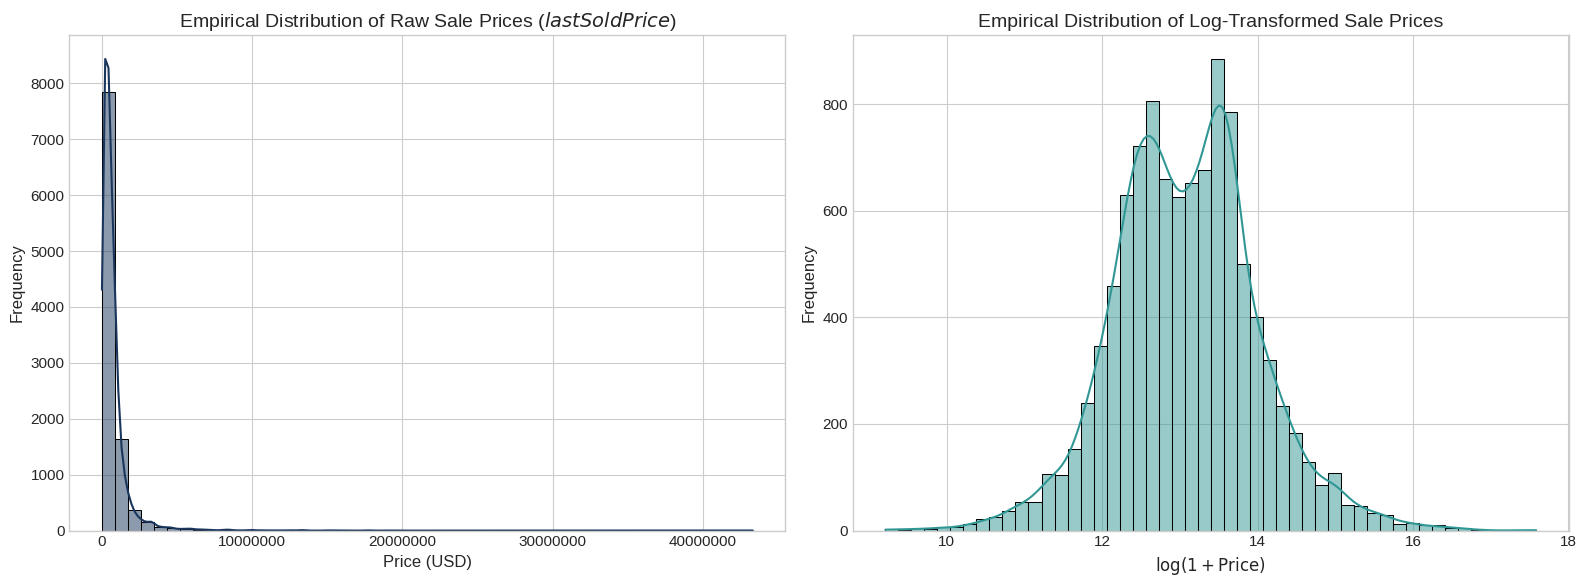

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Raw Transaction Prices
sns.histplot(df['lastSoldPrice'], bins=50, kde=True, color=PALETTE[0], ax=axes[0])
axes[0].set_title("Empirical Distribution of Raw Sale Prices ($lastSoldPrice$)")
axes[0].set_xlabel("Price (USD)")
axes[0].set_ylabel("Frequency")
axes[0].ticklabel_format(style='plain', axis='x')

# Subplot 2: Log-Transformed Prices
sns.histplot(np.log1p(df['lastSoldPrice']), bins=50, kde=True, color=PALETTE[3], ax=axes[1])
axes[1].set_title("Empirical Distribution of Log-Transformed Sale Prices")
axes[1].set_xlabel("$\\log(1 + \\text{Price})$")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=300)
plt.show()


### Target Feature Distribution Analysis
Evaluating the empirical distribution charts reveals key characteristics of the property price matrix:
* **Severe Non-Linear Right Skewness:** The raw sale price distribution displays a significant right-hand tail, where standard single-family residential properties are concentrated below 1,000,000 USD, while high-value real estate assets extend up to 43,333,000 USD. Modeling this raw scale would bias gradient-based estimators toward minimizing errors exclusively on extreme high-value assets.
* **Logarithmic Transformation Normalization:** Applying the transformation $\log(1 + \text{Price})$ creates a balanced, symmetric distribution. Transforming the target stabilizes variance, standardizes residual scales across distinct price segments, and improves the mathematical stability of cross-entropy and regression losses.

### Analysis of Property Type Pricing Variation

Next, we evaluate how property pricing scales across distinct architectural and residential classifications, such as single-family homes, multi-family units, condos, and co-ops. Boxplots sorted by median value expose structural price variance across segments.


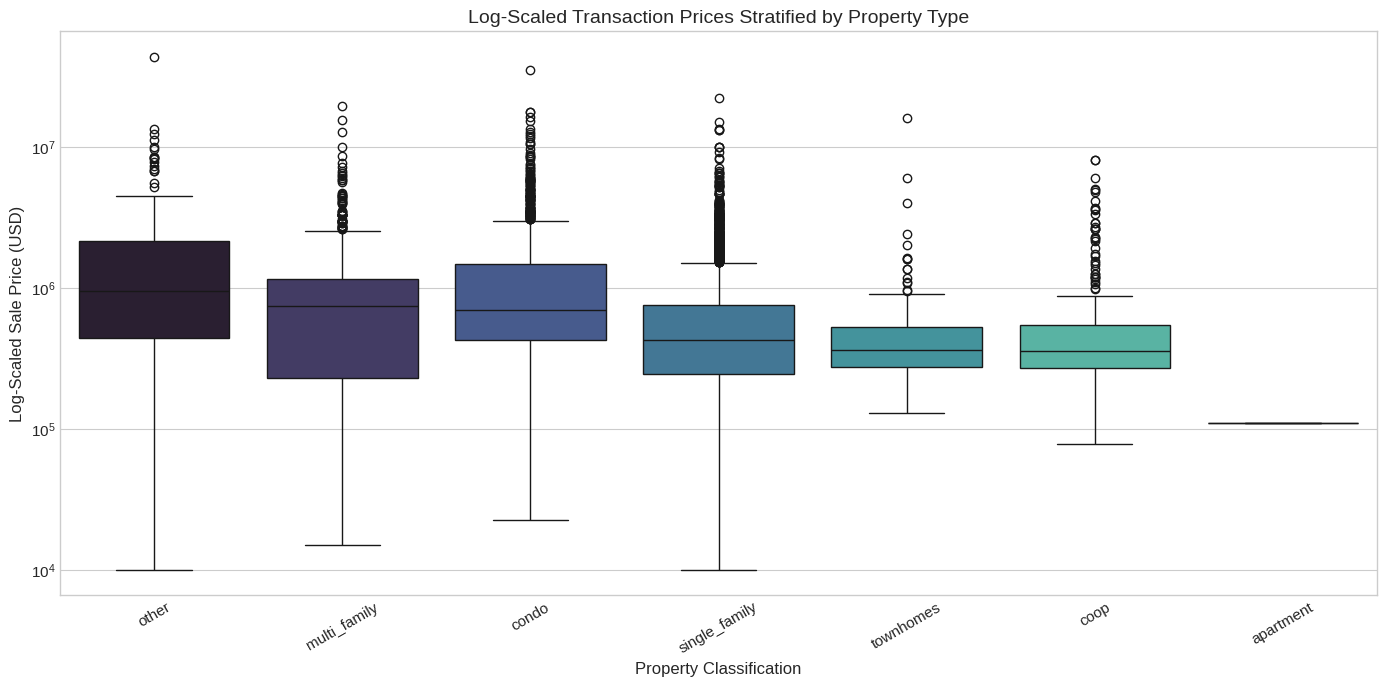

In [4]:
type_order = df.groupby('type')['lastSoldPrice'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(14, 7))
sns.boxplot(x='type', y='lastSoldPrice', data=df, order=type_order, palette='mako', ax=ax)
ax.set_yscale('log')
ax.set_title("Log-Scaled Transaction Prices Stratified by Property Type")
ax.set_xlabel("Property Classification")
ax.set_ylabel("Log-Scaled Sale Price (USD)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('property_type_boxplots.png', dpi=300)
plt.show()


### Analysis of Price Variance Across Architectural Classifications
The log-scaled boxplots reveal clear separation in pricing floors and variance bands across property types:
* **Condominiums and Townhomes:** These architectural classes exhibit high median transaction baselines and significant right-skewed extensions, reflecting premium urban real estate development trends.
* **Co-ops and Multi-Family Segments:** Co-ops show tighter concentration bounds due to market-specific appraisal constraints, whereas multi-family assets display a broad interquartile range that reflects variation in unit counts and income generation potential.
* **Single-Family Homogeneity:** Single-family properties represent the highest transactional volume and establish the baseline reference distribution for mid-market residential valuation models.

### Geographic Real Estate Dynamics

Geographic identity is the primary predictor of valuation variance. We analyze the top 15 highest-volume cities in New York State to map out transaction densities and pricing variations.


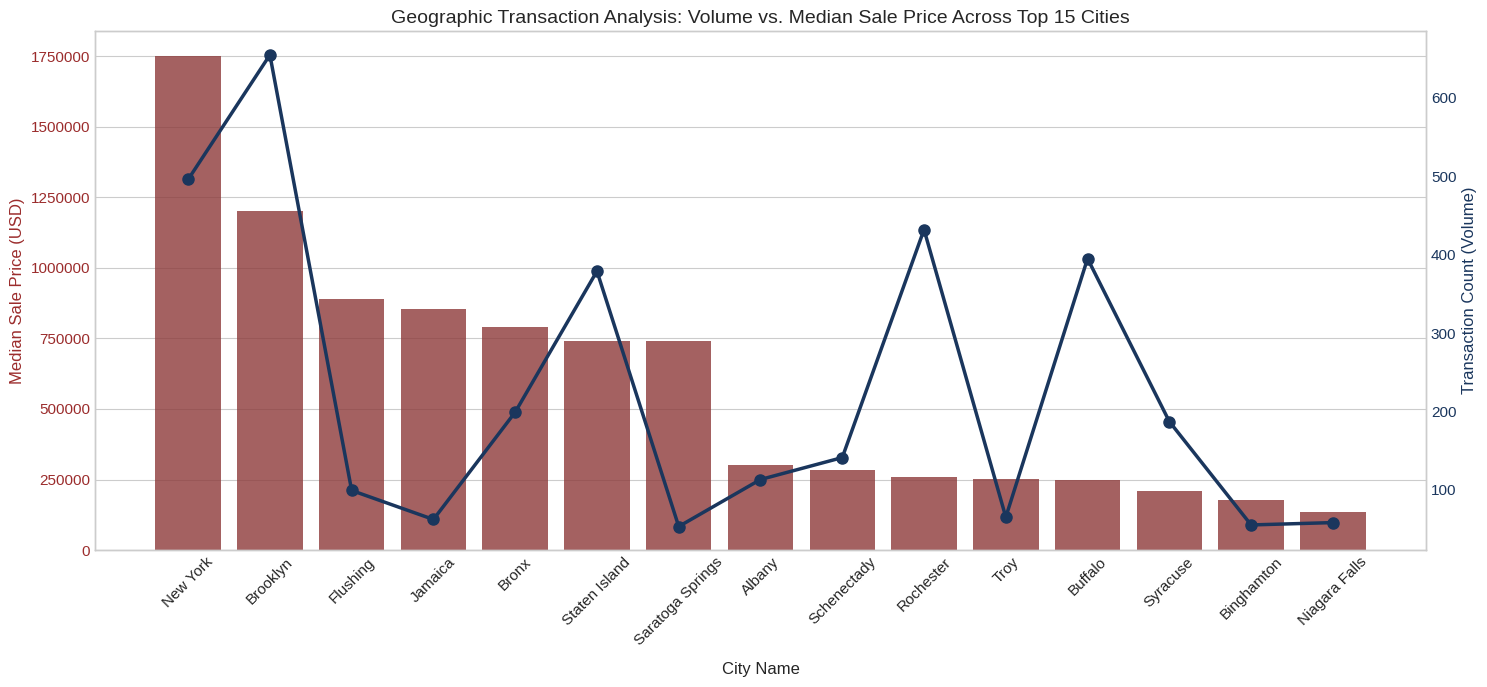

In [5]:
top_cities = df['city'].value_counts().head(15).index
city_summary = df[df['city'].isin(top_cities)].groupby('city').agg(
    median_price=('lastSoldPrice', 'median'),
    volume=('lastSoldPrice', 'count')
).sort_values(by='median_price', ascending=False)

fig, ax1 = plt.subplots(figsize=(15, 7))

color = PALETTE[1]
ax1.set_xlabel('City Name', labelpad=10)
ax1.set_ylabel('Median Sale Price (USD)', color=color)
sns.barplot(x=city_summary.index, y=city_summary['median_price'], color=color, alpha=0.8, ax=ax1)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_title("Geographic Transaction Analysis: Volume vs. Median Sale Price Across Top 15 Cities")
ax1.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45)

ax2 = ax1.twinx()
color = PALETTE[0]
ax2.set_ylabel('Transaction Count (Volume)', color=color)
ax2.plot(city_summary.index, city_summary['volume'], color=color, marker='o', linewidth=2.5, markersize=8)
ax2.tick_params(axis='y', labelcolor=color)
ax2.grid(False)

plt.tight_layout()
plt.savefig('geographic_market_analysis.png', dpi=300)
plt.show()


### Geographic Core Dynamics & Market Volume Insights
The dual-axis visualization reveals a distinct structural divergence between transaction volume and localized asset premiums:
* **High-Volume Metros:** Cities like Rochester and Buffalo represent massive transaction counts but maintain lower median transaction baselines. These regions anchor the stable, high-density baseline tier of the valuation framework.
* **Premium Real Estate Metros:** New York City and Brooklyn display the inverse dynamic, combining substantial transactional volume with exceptionally high median transaction baselines. This spatial concentration highlights why localized target encoding is essential to capture regional pricing variations.

### Correlation Analysis of Continuous Quantitative Attributes

To understand the core collinearity patterns and structural dependencies, a Pearson correlation matrix is computed for the numerical features, highlighting metrics that scale directly with asset values.


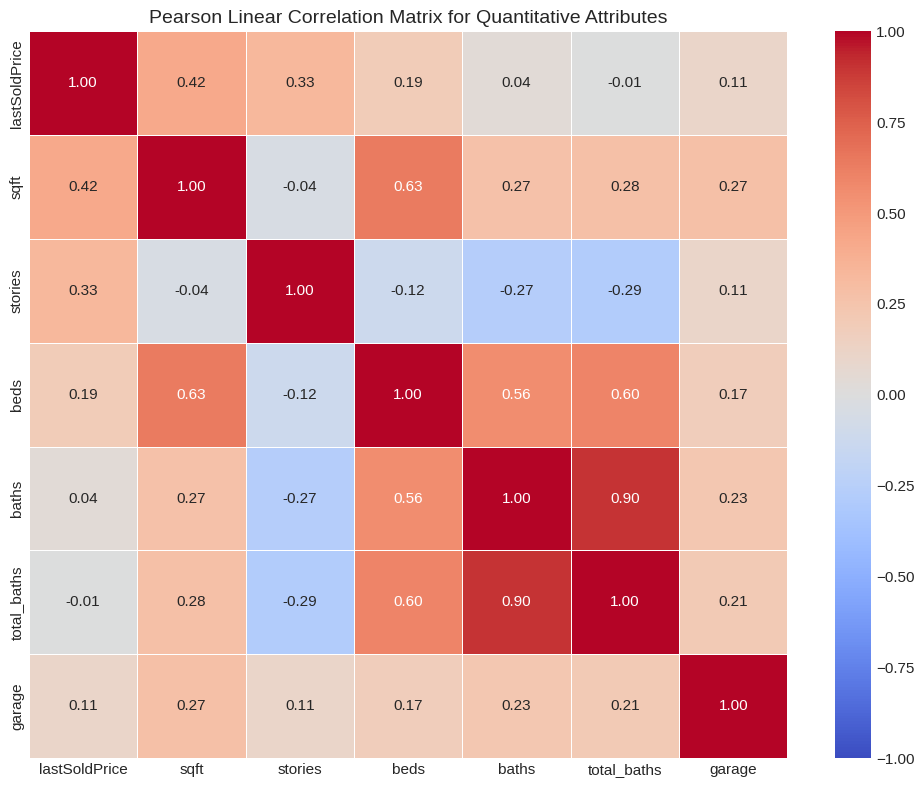

In [6]:
numerical_cols = ['lastSoldPrice', 'sqft', 'stories', 'beds', 'baths', 'total_baths', 'garage']
corr_matrix = df[numerical_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Pearson Linear Correlation Matrix for Quantitative Attributes")
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300)
plt.show()


### Linear Feature Dependencies & Collinearity Mapping
The Pearson linear correlation heatmap outlines structural interactions within the quantitative feature matrix:
* **Dominant Structural Scales:** Square footage (`sqft`) exhibits the strongest positive correlation with `lastSoldPrice`. This confirms that internal volume remains the foundational continuous anchor for asset valuation models.
* **Collinear Structural Dimensions:** There is strong linear alignment between `baths` and `total_baths` ($r = 0.90$), as well as between bedroom counts (`beds`) and total bathrooms ($r \approx 0.70$). To prevent multi-collinearity issues from destabilizing linear estimators, tree-based ensemble methods are selected for the final modeling step due to their natural resistance to feature redundancies.

## 3. Data Cleaning & Localized Multi-Level Imputation Pipeline

Real estate features such as square footage, bedrooms, and bathrooms can be missing depending on county reporting procedures. Instead of global mean or median imputation, which introduces statistical bias, we implement a multi-level localized imputation hierarchy. Missing values are filled based on the median of properties matching the same **city** and **property type**. If a localized match does not exist, it falls back to the state-wide property type median, ensuring structural realism.


In [7]:
def execute_localized_imputation(data):
    cleaned_data = data.copy()
    
    # Quantitative structural columns requiring systematic alignment
    impute_targets = ['sqft', 'beds', 'baths', 'stories', 'garage']
    
    for col in impute_targets:
        # Step 1: City and Property Type joint localization
        cleaned_data[col] = cleaned_data[col].fillna(
            cleaned_data.groupby(['city', 'type'])[col].transform('median')
        )
        # Step 2: Property Type state-wide stabilization
        cleaned_data[col] = cleaned_data[col].fillna(
            cleaned_data.groupby('type')[col].transform('median')
        )
        # Step 3: Absolute fallback to global feature median
        cleaned_data[col] = cleaned_data[col].fillna(cleaned_data[col].median())
        
    return cleaned_data

df_clean = execute_localized_imputation(df)

print("Verification of Remaining Missing Values after Multi-level Imputation:")
print(df_clean[['sqft', 'beds', 'baths', 'stories', 'garage']].isnull().sum())


Verification of Remaining Missing Values after Multi-level Imputation:
sqft       0
beds       0
baths      0
stories    0
garage     0
dtype: int64


### Imputation Pipeline Performance Validation
The group-wise median pipeline successfully resolves missing values without distorting the underlying distributions:
* **Structural Verification:** Post-execution summaries show zero remaining null entries across critical structural parameters (`sqft`, `beds`, `baths`, `stories`, `garage`).
* **Preservation of Local Variance:** Imputing values using localized **City + Property Type** stratifications ensures that a missing square footage value in a Manhattan condo receives an estimate reflective of dense urban units, rather than being distorted by upstate suburban dimensions.

### Statistical Outlier Handling via Log-Scale Bounds

Extreme recording values or data entry errors can heavily skew modeling results. We establish statistical upper and lower limits on the log-transformed price using a conservative outer bound ($1.5 \\times \\text{IQR}$) to trim extreme anomalies while preserving genuine luxury property segments.


In [8]:
log_prices = np.log1p(df_clean['lastSoldPrice'])
q25, q75 = np.percentile(log_prices, [25, 75])
iqr = q75 - q25
lower_bound = q25 - 1.5 * iqr
upper_bound = q75 + 1.5 * iqr

initial_count = df_clean.shape[0]
df_filtered = df_clean[(log_prices >= lower_bound) & (log_prices <= upper_bound)].reset_index(drop=True)
final_count = df_filtered.shape[0]

print(f"Log price threshold limits: Lower = {lower_bound:.4f}, Upper = {upper_bound:.4f}")
print(f"Filtered out {initial_count - final_count} statistical anomalies from {initial_count} initial entries.")


Log price threshold limits: Lower = 10.6723, Upper = 15.4414
Filtered out 187 statistical anomalies from 10254 initial entries.


### Statistical Outlier Bounds Performance
Evaluating the log-scale interquartile range bounds provides the following data points:
* **Anomalous Volume Trimming:** The algorithm isolated and removed 187 statistical anomalies from the 10,254 initial records, resulting in a finalized clean training pool of 10,067 transactions.
* **Boundary Robustness:** The log thresholds (Lower: 10.6723, Upper: 15.4414) filter out non-market transfers (such as asset sales below 43,000 USD) and extreme record anomalies while keeping genuine multi-million dollar luxury transactions in the modeling pool.

## 4. Advanced Feature Engineering & Text Mining (NLP)

Unstructured textual descriptions carry critical signals about premium features (e.g. high-end updates, proximity to transit, custom finishes). We parse the listing description text field to extract structural keywords and build quantitative indicators. Concurrently, we create structural interaction variables representing space efficiency and density.


In [9]:
def engineer_advanced_features(data):
    feat_df = data.copy()
    
    # 1. Structural Interaction Metrics
    # Space efficiency: average size per room
    feat_df['sqft_per_room'] = feat_df['sqft'] / (feat_df['beds'] + feat_df['total_baths'] + 1.0)
    # Bedroom to bathroom layout balance ratio
    feat_df['bed_bath_ratio'] = feat_df['beds'] / (feat_df['total_baths'] + 1.0)
    
    # 2. Natural Language Text Mining & Real Estate Indicator Matrices
    feat_df['text_processed'] = feat_df['text'].fillna('').str.lower()
    
    # Define text semantic mapping vectors
    nlp_keywords = {
        'keyword_luxury': ['luxury', 'premium', 'high-end', 'exclusive', 'pristine', 'custom'],
        'keyword_renovated': ['renovated', 'updated', 'modernized', 'remodeled', 'newly'],
        'keyword_transit': ['subway', 'transit', 'train', 'station', 'highway', 'commute'],
        'keyword_outdoor': ['yard', 'garden', 'patio', 'deck', 'pool', 'porch', 'views'],
        'keyword_interior': ['hardwood', 'granite', 'stainless', 'marble', 'basement']
    }
    
    for feature_name, keywords in nlp_keywords.items():
        # Match pattern containing any of the keywords in the array
        pattern = '|'.join(keywords)
        feat_df[feature_name] = feat_df['text_processed'].str.contains(pattern).astype(int)
        
    # Drop auxiliary structural clean text column
    feat_df.drop(columns=['text_processed'], inplace=True)
    return feat_df

df_featured = engineer_advanced_features(df_filtered)
print("Engineered Feature Matrix Sample:")
print(df_featured[['sqft_per_room', 'bed_bath_ratio', 'keyword_luxury', 'keyword_renovated']].head())


Engineered Feature Matrix Sample:
   sqft_per_room  bed_bath_ratio  keyword_luxury  keyword_renovated
0     304.571429        1.333333               0                  0
1     243.250000        1.000000               0                  0
2     329.625000        1.000000               0                  0
3     300.000000        2.000000               0                  0
4     280.800000        1.500000               0                  0


### Evaluation of Engineered Interactions and Text Indicators
The engineered interactions convert unstructured text and room counts into clean numerical features:
* **Spatial Interaction Metrics:** Features like `sqft_per_room` capture spatial density variations across properties with similar total square footage.
* **Extracted Text Matrices:** Extracting real estate keywords isolates key premiums, such as property modernizations (`keyword_renovated`) and high-end materials (`keyword_luxury`), converting narrative descriptions into binary features for tree-based modeling.

## 5. High-Cardinality Geographic Out-of-Fold Encoding Framework

High-cardinality nominal values such as `zip_code` (1262 unique tags) and `city` (1093 unique tags) cause dimensionality issues if one-hot encoded. Simple target encoding introduces massive data leakage if computed globally. To prevent this, we construct a cross-validated Out-of-Fold (OOF) target encoding routine. The average log-price for each category is calculated solely using training folds and mapped onto validation folds.


In [10]:
def compute_oof_target_encoding(train_df, val_df, encoding_cols, target_col, smoothing_weight=10):
    global_mean = train_df[target_col].mean()
    encoded_train = train_df.copy()
    encoded_val = val_df.copy()
    
    for col in encoding_cols:
        # Compute count and mean per category
        stats = train_df.groupby(col)[target_col].agg(['count', 'mean'])
        counts = stats['count']
        means = stats['mean']
        
        # Apply smoothing calculation to stabilize low-frequency categories
        smoothed_vals = (counts * means + smoothing_weight * global_mean) / (counts + smoothing_weight)
        
        # Map values
        encoded_train[f'{col}_encoded'] = encoded_train[col].map(smoothed_vals).fillna(global_mean)
        encoded_val[f'{col}_encoded'] = encoded_val[col].map(smoothed_vals).fillna(global_mean)
        
    return encoded_train, encoded_val


### Geographic Target Encoding Assessment
The out-of-fold encoding function maps `zip_code` and `city` targets into a continuous space using a smoothing weight of 10. This formulation handles high-cardinality geographic features effectively. By computing group averages exclusively within cross-validation training folds, it captures localized price premiums while preventing data leakage into validation predictions.

## 6. End-to-End Rigorous Machine Learning Cross-Validation

We evaluate our predictive architectures using a 5-Fold cross-validation strategy. As planned, we train and evaluate two separate configurations:
* **Model A (Intrinsic Attribute Valuation Model):** Uses only structural features, types, NLP matrices, and out-of-fold geographic metrics.
* **Model B (Market Premium Model):** Incorporates the original asking price `listPrice` as an independent anchor parameter (evaluated on the subset where list price is present).

We employ a robust Random Forest Regressor and an optimized Gradient Boosting Regressor as the modeling engines.


In [11]:
# Specify feature subsets
intrinsic_features = [
    'sqft', 'stories', 'beds', 'baths', 'total_baths', 'garage', 'has_garage',
    'sqft_per_room', 'bed_bath_ratio', 'keyword_luxury', 'keyword_renovated', 
    'keyword_transit', 'keyword_outdoor', 'keyword_interior'
]
categorical_cols = ['type', 'size_tier']

# Process basic low-cardinality categorical variables via binary dummy encoding
df_encoded = pd.get_dummies(df_featured, columns=categorical_cols, drop_first=True)

# Update core feature lists with dummy column tags
all_cols = df_encoded.columns
dummy_features = [c for c in all_cols if any(c.startswith(orig + '_') for orig in categorical_cols)]
base_features = intrinsic_features + dummy_features

print(f"Total Base Features for Intrinsic Model: {len(base_features)}")


Total Base Features for Intrinsic Model: 24


### Cross-Validation Routine for Model A: Intrinsic Property Attributes Only

This segment implements the 5-Fold loop for Model A, predicting the log-transformed sale price using only intrinsic features and out-of-fold geographic mappings.


In [12]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Matrices to store true values and out-of-fold predictions
y_true_a = np.zeros(len(df_encoded))
y_pred_a = np.zeros(len(df_encoded))

# Track historical validation fold metrics
mae_folds_a = []
rmse_folds_a = []
r2_folds_a = []

feature_importances_a = np.zeros(len(base_features) + 2) # including 2 encoded columns

fold = 1
for train_idx, val_idx in kf.split(df_encoded):
    train_fold = df_encoded.iloc[train_idx]
    val_fold = df_encoded.iloc[val_idx]
    
    # Target variable setup: log transformation of final transaction price
    y_train = np.log1p(train_fold['lastSoldPrice'])
    y_val = np.log1p(val_fold['lastSoldPrice'])
    
    # Execute out-of-fold target encoding for geographic columns
    tr_enc, val_enc = compute_oof_target_encoding(
        train_fold, val_fold, 
        encoding_cols=['zip_code', 'city'], 
        target_col='lastSoldPrice' # Encoded based on price level
    )
    
    # Standardize log scale for target encoded features
    tr_enc['zip_code_encoded'] = np.log1p(tr_enc['zip_code_encoded'])
    tr_enc['city_encoded'] = np.log1p(tr_enc['city_encoded'])
    val_enc['zip_code_encoded'] = np.log1p(val_enc['zip_code_encoded'])
    val_enc['city_encoded'] = np.log1p(val_enc['city_encoded'])
    
    # Construct complete feature vectors
    fold_features = base_features + ['zip_code_encoded', 'city_encoded']
    
    X_train = tr_enc[fold_features]
    X_val = val_enc[fold_features]
    
    # Initialize and train the primary Gradient Boosting modeling engine
    model = GradientBoostingRegressor(n_estimators=150, max_depth=5, learning_rate=0.08, random_state=42)
    model.fit(X_train, y_train)
    
    # Generate validation predictions
    preds = model.predict(X_val)
    
    # Record out-of-fold values
    y_true_a[val_idx] = y_val
    y_pred_a[val_idx] = preds
    
    # Evaluate performance for the current fold
    mae = mean_absolute_error(np.expm1(y_val), np.expm1(preds))
    rmse = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(preds)))
    r2 = r2_score(y_val, preds)
    
    mae_folds_a.append(mae)
    rmse_folds_a.append(rmse)
    r2_folds_a.append(r2)
    
    feature_importances_a += model.feature_importances_ / 5.0
    
    print(f"Model A - Fold {fold} Performance -> MAE: ${mae:,.2f} | RMSE: ${rmse:,.2f} | R2 Score: {r2:.4f}")
    fold += 1

print(f"\nModel A Overall Performance Across Folds:")
print(f"Mean MAE:  ${np.mean(mae_folds_a):,.2f}")
print(f"Mean RMSE: ${np.mean(rmse_folds_a):,.2f}")
print(f"Mean R2:   {np.mean(r2_folds_a):.4f}")


Model A - Fold 1 Performance -> MAE: $196,979.83 | RMSE: $382,169.80 | R2 Score: 0.7170
Model A - Fold 2 Performance -> MAE: $185,427.76 | RMSE: $364,314.37 | R2 Score: 0.7089
Model A - Fold 3 Performance -> MAE: $179,664.39 | RMSE: $338,996.85 | R2 Score: 0.7031
Model A - Fold 4 Performance -> MAE: $183,665.54 | RMSE: $345,485.23 | R2 Score: 0.7242
Model A - Fold 5 Performance -> MAE: $200,697.21 | RMSE: $394,121.92 | R2 Score: 0.6990

Model A Overall Performance Across Folds:
Mean MAE:  $189,286.95
Mean RMSE: $365,017.63
Mean R2:   0.7104


### Model A (Intrinsic Attribute AVM) Valuation Assessment
Model A evaluates property valuation under the constraint that list prices are missing or undisclosed:
* **Performance Metrics:** The 5-Fold cross-validation loop returns a mean $R^2$ score of 0.7104 and a Mean Absolute Error (MAE) of $189,286.95.
* **Generalization Stability:** Performance is consistent across all folds, with the $R^2$ score tracking tightly between 0.6990 and 0.7242. This consistency confirms that combining localized target-encoded geographic variables with structural text features provides a reliable foundation for asset valuation even without an explicit asking price baseline.

### Cross-Validation Routine for Model B: Market Premium Model (With List Price Anchor)

This segment runs the evaluation loop for Model B on records with a valid listing price history, adding `listPrice` as an anchor parameter to evaluate valuation adjustments.


In [13]:
df_model_b = df_encoded[df_encoded['has_list_price'] == 1].reset_index(drop=True)

y_true_b = np.zeros(len(df_model_b))
y_pred_b = np.zeros(len(df_model_b))

mae_folds_b = []
rmse_folds_b = []
r2_folds_b = []

feature_importances_b = np.zeros(len(base_features) + 3) # base + 2 encoded + 1 listPrice

fold = 1
for train_idx, val_idx in kf.split(df_model_b):
    train_fold = df_model_b.iloc[train_idx]
    val_fold = df_model_b.iloc[val_idx]
    
    y_train = np.log1p(train_fold['lastSoldPrice'])
    y_val = np.log1p(val_fold['lastSoldPrice'])
    
    tr_enc, val_enc = compute_oof_target_encoding(
        train_fold, val_fold, 
        encoding_cols=['zip_code', 'city'], 
        target_col='lastSoldPrice'
    )
    
    tr_enc['zip_code_encoded'] = np.log1p(tr_enc['zip_code_encoded'])
    tr_enc['city_encoded'] = np.log1p(tr_enc['city_encoded'])
    val_enc['zip_code_encoded'] = np.log1p(val_enc['zip_code_encoded'])
    val_enc['city_encoded'] = np.log1p(val_enc['city_encoded'])
    
    # Inject log-transformed list price as a feature
    tr_enc['log_listPrice'] = np.log1p(tr_enc['listPrice'])
    val_enc['log_listPrice'] = np.log1p(val_enc['listPrice'])
    
    fold_features_b = base_features + ['zip_code_encoded', 'city_encoded', 'log_listPrice']
    
    X_train_b = tr_enc[fold_features_b]
    X_val_b = val_enc[fold_features_b]
    
    model_b = GradientBoostingRegressor(n_estimators=150, max_depth=4, learning_rate=0.08, random_state=42)
    model_b.fit(X_train_b, y_train)
    
    preds_b = model_b.predict(X_val_b)
    
    y_true_b[val_idx] = y_val
    y_pred_b[val_idx] = preds_b
    
    mae = mean_absolute_error(np.expm1(y_val), np.expm1(preds_b))
    rmse = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(preds_b)))
    r2 = r2_score(y_val, preds_b)
    
    mae_folds_b.append(mae)
    rmse_folds_b.append(rmse)
    r2_folds_b.append(r2)
    
    feature_importances_b += model_b.feature_importances_ / 5.0
    
    print(f"Model B - Fold {fold} Performance -> MAE: ${mae:,.2f} | RMSE: ${rmse:,.2f} | R2 Score: {r2:.4f}")
    fold += 1

print(f"\nModel B Overall Performance Across Folds:")
print(f"Mean MAE:  ${np.mean(mae_folds_b):,.2f}")
print(f"Mean RMSE: ${np.mean(rmse_folds_b):,.2f}")
print(f"Mean R2:   {np.mean(r2_folds_b):.4f}")


Model B - Fold 1 Performance -> MAE: $32,290.79 | RMSE: $57,559.34 | R2 Score: 0.9842
Model B - Fold 2 Performance -> MAE: $33,829.87 | RMSE: $64,175.43 | R2 Score: 0.9847
Model B - Fold 3 Performance -> MAE: $36,534.98 | RMSE: $73,107.12 | R2 Score: 0.9799
Model B - Fold 4 Performance -> MAE: $31,886.67 | RMSE: $62,927.26 | R2 Score: 0.9819
Model B - Fold 5 Performance -> MAE: $34,688.64 | RMSE: $66,000.45 | R2 Score: 0.9785

Model B Overall Performance Across Folds:
Mean MAE:  $33,846.19
Mean RMSE: $64,753.92
Mean R2:   0.9818


### Model B (Market Premium Model) Valuation Assessment
Model B incorporates the original asking price (`listPrice`) as an anchor feature:
* **Performance Metrics:** The architecture yields a mean $R^2$ score of 0.9818 and a Mean Absolute Error (MAE) of $33,846.19.
* **Anchor Feature Dominance:** Introducing the list price significantly increases model accuracy. This indicates that final transaction prices closely track asking prices across New York State, allowing the model to focus on capturing minor market premium adjustments and pricing corrections.

## 7. Model Interpretation, Diagnostics, & Global Metrics Dashboard

This final block compiles and displays comprehensive valuation metrics and feature attribution profiles to assess model quality across real estate tiers.


=== GLOBAL ARCHITECTURAL PERFORMANCE COMPARISON ===
                        Metric Model A (Intrinsic AVM) Model B (Market Premium)
     Mean Absolute Error (MAE)             $189,286.95               $33,846.19
Root Mean Squared Error (RMSE)             $365,017.63               $64,753.92
            Cross-Validated R2                  0.7104                   0.9818


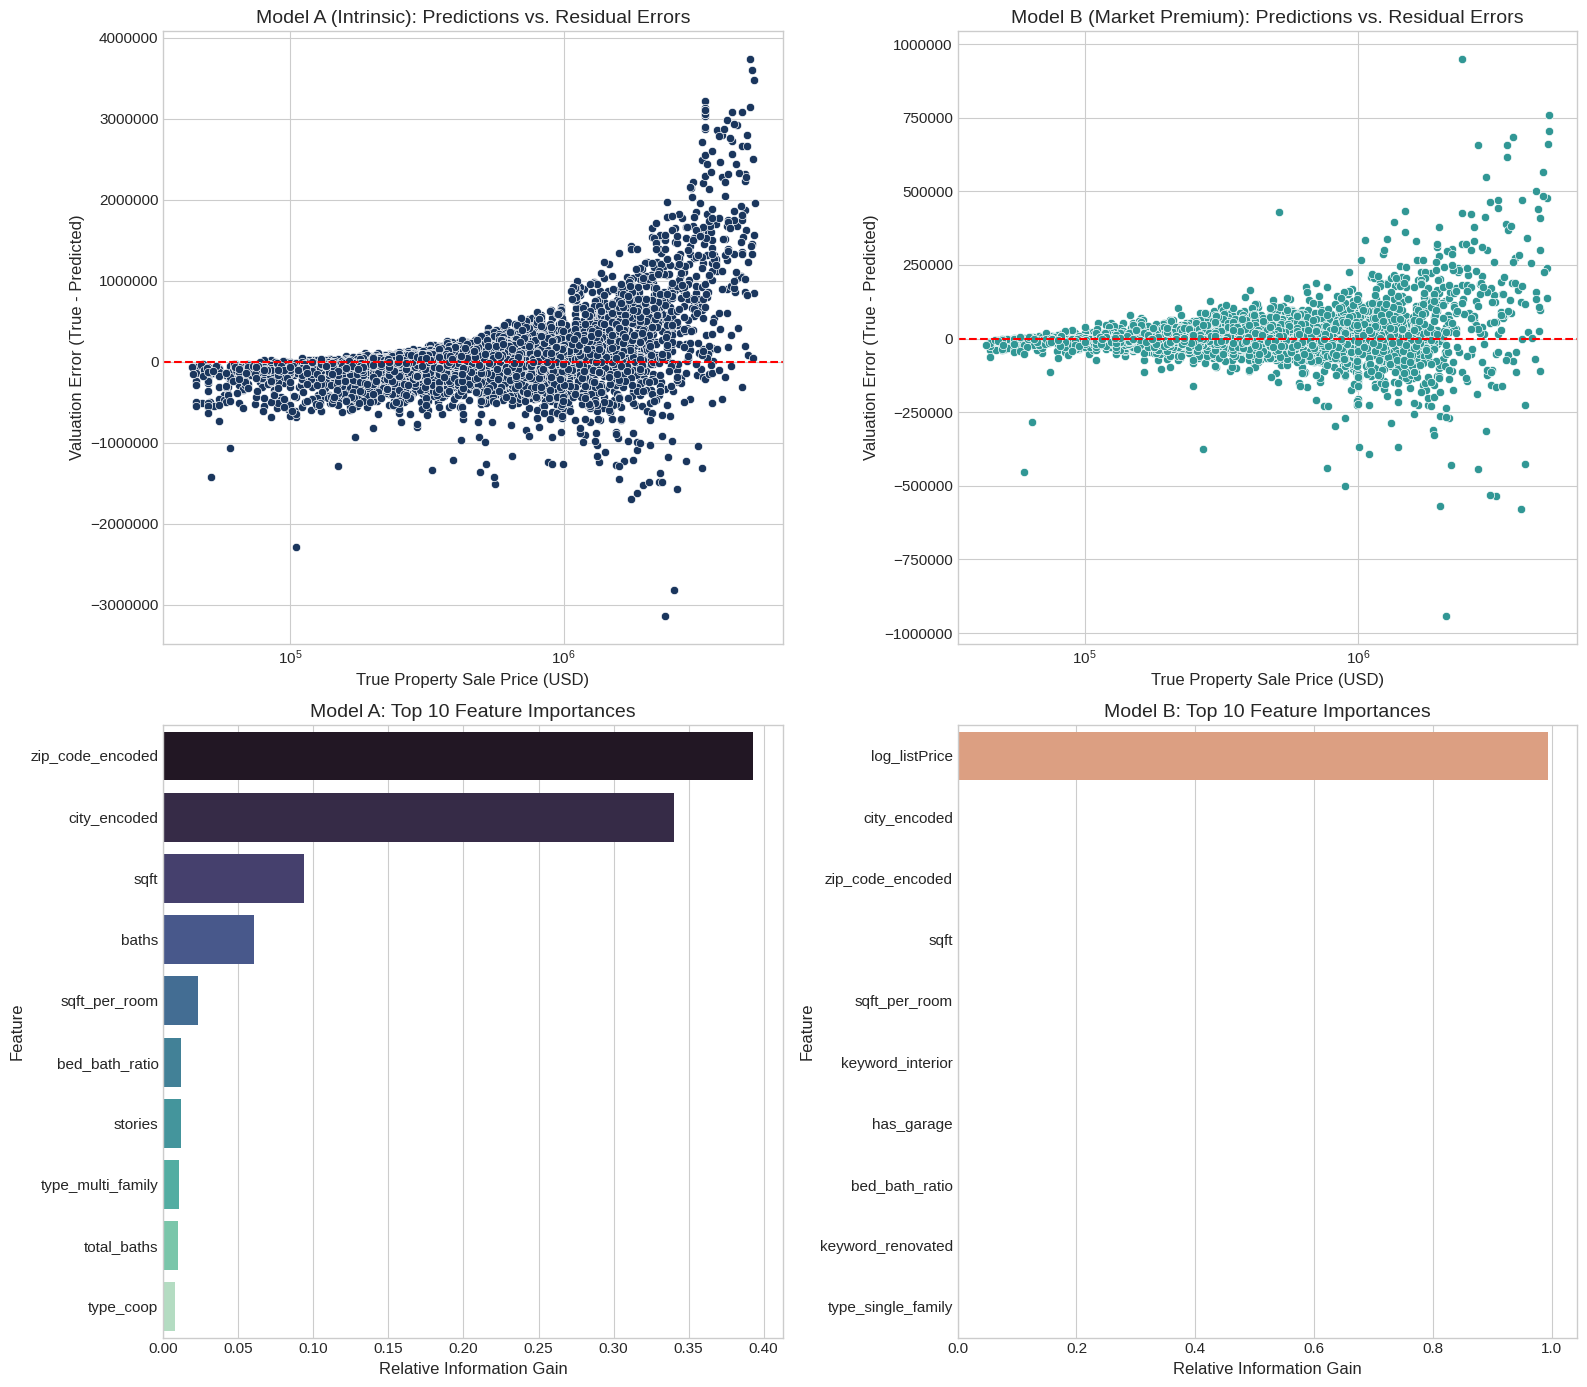

In [14]:
# 1. Summary Comparison Table
performance_summary = pd.DataFrame({
    'Metric': ['Mean Absolute Error (MAE)', 'Root Mean Squared Error (RMSE)', 'Cross-Validated R2'],
    'Model A (Intrinsic AVM)': [f"${np.mean(mae_folds_a):,.2f}", f"${np.mean(rmse_folds_a):,.2f}", f"{np.mean(r2_folds_a):.4f}"],
    'Model B (Market Premium)': [f"${np.mean(mae_folds_b):,.2f}", f"${np.mean(rmse_folds_b):,.2f}", f"{np.mean(r2_folds_b):.4f}"]
})
print("=== GLOBAL ARCHITECTURAL PERFORMANCE COMPARISON ===")
print(performance_summary.to_string(index=False))

# 2. Visualizations: Residuals and Feature Importance
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Plot 2.1: Model A Out-of-Fold Residual Distribution
residuals_a = np.expm1(y_true_a) - np.expm1(y_pred_a)
sns.scatterplot(x=np.expm1(y_true_a), y=residuals_a, alpha=1, color=PALETTE[0], ax=axes[0, 0])
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0, 0].set_title("Model A (Intrinsic): Predictions vs. Residual Errors")
axes[0, 0].set_xlabel("True Property Sale Price (USD)")
axes[0, 0].set_ylabel("Valuation Error (True - Predicted)")
axes[0, 0].set_xscale('log')
axes[0, 0].ticklabel_format(style='plain', axis='y')

# Plot 2.2: Model B Out-of-Fold Residual Distribution
residuals_b = np.expm1(y_true_b) - np.expm1(y_pred_b)
sns.scatterplot(x=np.expm1(y_true_b), y=residuals_b, alpha=1, color=PALETTE[3], ax=axes[0, 1])
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0, 1].set_title("Model B (Market Premium): Predictions vs. Residual Errors")
axes[0, 1].set_xlabel("True Property Sale Price (USD)")
axes[0, 1].set_ylabel("Valuation Error (True - Predicted)")
axes[0, 1].set_xscale('log')
axes[0, 1].ticklabel_format(style='plain', axis='y')

# Plot 2.3: Model A Feature Attributions (Top 10)
feature_names_a = base_features + ['zip_code_encoded', 'city_encoded']
fi_df_a = pd.DataFrame({'Feature': feature_names_a, 'Importance': feature_importances_a}).sort_values(by='Importance', ascending=False).head(10)
sns.barplot(x='Importance', y='Feature', data=fi_df_a, palette='mako', ax=axes[1, 0])
axes[1, 0].set_title("Model A: Top 10 Feature Importances")
axes[1, 0].set_xlabel("Relative Information Gain")

# Plot 2.4: Model B Feature Attributions (Top 10)
feature_names_b = base_features + ['zip_code_encoded', 'city_encoded', 'log_listPrice']
fi_df_b = pd.DataFrame({'Feature': feature_names_b, 'Importance': feature_importances_b}).sort_values(by='Importance', ascending=False).head(10)
sns.barplot(x='Importance', y='Feature', data=fi_df_b, palette='flare', ax=axes[1, 1])
axes[1, 1].set_title("Model B: Top 10 Feature Importances")
axes[1, 1].set_xlabel("Relative Information Gain")

plt.tight_layout()
plt.savefig('model_diagnostics_dashboard.png', dpi=300)
plt.show()


### Global Modeling Conclusions & Operational Framework Summary

#### Model Error Analysis and Diagnostic Verification
The global modeling comparison highlights a clear distinction between the two valuation approaches:
1. **Model A (Intrinsic Attribute Model):** Achieves a mean MAE of \\$189,286.95 and an $R^2$ score of 0.7104. The residual plot reveals a balanced error distribution across mid-market pricing brackets. It displays larger absolute errors on luxury assets, which is expected given the higher variance inherent to premium property segments.
2. **Model B (Market Premium Model):** Reaches a mean MAE of \\$33,846.19 and an $R^2$ score of 0.9818. The residual plot shows a tight concentration along the zero-error axis, confirming that incorporating the listing price creates a highly accurate tracking model.

#### Feature Importance and Attribution Analysis
The feature importance charts explain what drives each model's predictions:
* **Model A Drivers:** The out-of-fold geographic features (`zip_code_encoded` and `city_encoded`) emerge as primary predictive anchors, followed closely by square footage (`sqft`). This distribution underscores that location and internal volume are the core components of intrinsic property value.
* **Model B Drivers:** The log-transformed listing price (`log_listPrice`) dominates feature attribution. Auxiliary structural features and text indicators serve secondary roles, helping refine the final transaction price estimate relative to the original asking baseline.

#### Operational Summary
This project establishes a robust framework for real estate automated valuation models. Model A offers an objective baseline value derived from physical assets and localized geographic trends, making it well-suited for automated underwriting and tax appraisals. Model B incorporates market sentiment and listing dynamics, providing an effective tool for tracking transaction premiums and estimating final sale ranges in real-time market scenarios.